<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Комментарий ревьюера</b>


Привет, Дмитрий! Давай знакомиться! Меня зовут Дмитрий Махортов, и я буду проверять твой проект. Сразу предлагаю общение на «ты» 🙂, но если тебе это не комфортно, то дай знать, и мы перейдем на «вы».


Моя основная цель — не указать на совершенные тобою ошибки, а поделиться своим опытом и помочь тебе погрузиться в увлекательный мир работы с данными и вырасти в крепкого профи. Это отдаленная цель. А ближайшая - сделать твою работу еще лучше )).
   
    
Все ключевые этапы в работе выполнены, и я вижу что с проектом ты справшяешься. Есть моменты, которые нужно доработать, но я уверен, у тебя все получится.
        
Расскажу как обычно проходит проверка:    
Бывают моменты, которые требуют пристального внимания. Комментарии по ним выделены <span style='background-color:#F7B3A4'> красным цветом </span> и обозначены значком 🛑. После их доработки проект будет принят.  🙂

<span style='background-color:#B7EBA7'> Зеленым цветом </span> и значком ✅ отмечены удачные и элегантные решения, на которые можно опираться в будущих проектах. Или советы «со звездочкой», которые помогут тебе в будущем.

<span style='background-color:#F9EDA6'>Жёлтым цветом </span> и значком ⚠️ выделено то, что в следующий раз можно сделать по-другому. Ты можешь учесть эти комментарии при выполнении будущих заданий или доработать проект сейчас (однако это не обязательно).

Давай работать над проектом в диалоге: **если ты что-то меняешь в проекте по моим рекомендациям — пиши об этом**. Выбери для своих комментариев какой-то заметный цвет, так мне будет легче отследить изменения. Пожалуйста, **не перемещай, не изменяй и не удаляй мои комментарии**. Всё это поможет выполнить повторную проверку твоего проекта оперативнее.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>образец комментария студента</b></font>
   
Можешь использовать этот комментарий. Просто удали этот текст и вместо него напиши свой 🙂

</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментария студента</b></font>
   
Дмитрий, приветствую! Зарание хотел поблагодарить за проверку и подсказку исправлений моего проекта

</div>

# 📌 Поиск изображений по текстовому описанию (PoC)

## Описание проекта

В рамках проекта разрабатывается демонстрационная версия системы поиска изображений по текстовому запросу для фотохостинга «Со Смыслом» (With Sense).

Пользователи публикуют фотографии и добавляют к ним текстовые описания. Предполагается реализовать функциональность, при которой пользователь вводит описание сцены, а система возвращает изображения с похожим содержанием.

Для защиты инициативы перед руководством необходимо подготовить Proof of Concept (PoC) — продемонстрировать практическую реализуемость решения.

Модель должна:
- получать векторное представление изображения;
- получать векторное представление текста;
- выдавать число от 0 до 1 — степень соответствия изображения и текста.

В проекте используется один фреймворк — Keras.

---

## Юридические ограничения

В ряде стран запрещена обработка и отображение контента, содержащего изображения или описания лиц младше 16 лет.

В рамках PoC необходимо:
- удалить подобный контент из обучающих данных;
- при появлении запрещённых слов в запросе выводить дисклеймер:  
  *“This image is unavailable in your country in compliance with local laws”*.

---

## Используемые данные

- `train_dataset.csv` — изображения и их описания  
- `CrowdAnnotations.tsv` — оценки соответствия от пользователей  
- `ExpertAnnotations.tsv` — экспертные оценки (шкала 1–4)  
- `test_queries.csv` — тестовые запросы  
- папки `train_images` и `test_images` — изображения для обучения и тестирования  

---

## Цель работы

Разработать модель, которая:
- объединяет текстовые и визуальные признаки;
- предсказывает релевантность пары «изображение–текст»;
- позволяет находить наиболее подходящие изображения по текстовому запросу.

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 Да, это хорошая практика - дать описание контекста и проблемы, которую мы решаем. </div>

In [54]:
# !pip install -q \
# numpy==1.26.4 \
# pandas==2.2.2 \
# scikit-learn==1.4.2 \
# matplotlib==3.8.4 \
# tqdm==4.66.4 \
# Pillow==10.3.0 \
# tensorflow==2.15.0
# !pip install sentence-transformers -q

In [55]:
# Импорт библеотек
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import Normalizer
from sentence_transformers import SentenceTransformer

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from PIL import Image, UnidentifiedImageError
from IPython.display import display

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Отлично, все нужные библиотеки импортированы в начале ноутбука.Это хорошая практика.</div>

## Загрузка данных

In [ ]:
!wget -q https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip
!unzip -q dsplus_integrated_project_4.zip

DATA_PATH = '/content/to_upload'

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
На мой взгляд привязка к локальному диску (или твоему личному гугл драйву) это не очень  удобно, т.к. у того, кто будет проверять твой проект свой диск и на нем нет датасета. Выходом может быть прямое закачивание датасета в сессию colab. Вот код для скачивания и извлечения данных из архива
    
    
    # загрузка датасета

    !wget -q https://code.s3.yandex.net/datasets/dsplus_integrated_project_4.zip
    !unzip -q dsplus_integrated_project_4.zip

    DATA_PATH = '/content/to_upload'
    
    
Также хорошей практикой является вынос пути к датасету в константу, которая видна в самом начале ноутбука. В этом случае для запуска твоего проекта с другими путями к данным достаточно просто изменить эту константу.
    
Еще момент - способы формирования путей в OS Linux и OS Windows различаются (ипользуются прямой и обратный слэш). Поэтому способ склейки через +"/"+ не универсальный. Лучше использовать os.path.join    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">
    <font size="3"><b>Комментария студента</b></font>
   
Поправил

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b>  👍


-------------
    
Сразу хочу сказать - мой комментарий скорее относился к воспроизводимости и конкретному кейсу.  Для личных проектов использование связки Colab  + Google Drive это очень удобный инструмент, позволяющий сохранять все ценные данные между сессиями, и хранить в Drive не только датасеты, но и промежуточные артефакты, например эмбеддинги или промежуточные веса (чекпоинты моделей), если обучение длится долго. Например у меня были проекты (пет проекты, стажировки), где обучение нейронок шло сутками, а перебор разных гиперпараметров занимал недели, поэтому очень важно сохранять промежуточные чекпоинты, чтобы в случае падения сессии иметь возможность легко возвращаться к стартовой точке.

</div>

In [57]:
train_df = pd.read_csv(os.path.join(DATA_PATH,'train_dataset.csv'), sep=',')
test_queries = pd.read_csv(os.path.join(DATA_PATH,'test_queries.csv'), sep='|', index_col=0)

crowd_df = pd.read_csv(os.path.join(DATA_PATH,'CrowdAnnotations.tsv'),
                       sep='\t',
                       header=None,
                       usecols=[0, 1, 2, 3, 4])  # индексы вместо имен

crowd_df.columns = ['image', 'query_id', 'people', 'count_people_true', 'count_people_false']

expert_df = pd.read_csv(os.path.join(DATA_PATH,'ExpertAnnotations.tsv'),
                        sep='\t',
                        header=None,
                        usecols=[0, 1, 2, 3, 4])  # индексы столбцов

expert_df.columns = ['image', 'query_id', 'estimation_1', 'estimation_2', 'estimation_3']


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">
Очень "больная тема" - это загрузка данных и использование путей.Очевидно, что на моей машине (и скорее всего машине любого другого пользователя) пути к данным будут другие. И это "рабочая ситуация для большинства проектов. Решается она следующим образом:

    
  - Путь к директории с данными  должен быть задан в константе, в самом начале работы. Тогда ревьюеру (или любому другому пользователю твоего ноутбука, даже тебе самому, если нужно будет провести презентацию руководителю на другом компьютере) нужно будет изменить только этот путь.
  - Все остальные пути внутри ноутбука должны быть созданы с исопользованием этой константы, а не заданы жестко (есть сленговое определение "хардкод").  Более  того, настоятельно рекомендую для создания сложных путей вместо простой конкатерации строк с исползованием '/' использовать os.path.join(), тогда код будет одинаково надежно работать и в среде Windows и Linux (MacOS).
   
Чтобы запустить твой код при проверке я был вынужден руками менять код по всему ноутбуку. Прошу тебя внести изменения так, чтобы путь к данным нужно было изменять всего один раз.


А вот это образец универсального кода для загрузки данных    
    
    DATA_PATH = твой путь    
    
    df_train = pd.read_csv(os.path.join(DATA_PATH, 'train_dataset.csv'))
    ....
    
    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">

<font size="3"><b>Комментария студента</b></font>

Поправил

  

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b> исправлено 👍 </div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">

В этом проекте у нас достаточно много датафреймов и разных этапов, поэтому критически важно подумать об оптимальной структуре, чтобы и тебе было удобно, четко понимать в какой раздел поместить ту или иную логику и ничего не пропустить, а коллегам будет гораздо проще знакомиться с проектом, если всё будет "по полочкам".  Каждый отдельный пункт - это отдельный подрзадел (выделенный заголвком), в нем есть своя логика: план, код и подведение итогов (что мы получили на этом этапе).

**Почему это важно:**
Профессиональный ML-проект — это не просто работающий скрипт, это **Pipeline**. Хорошая структура позволяет коллегам быстро понять твою логику, а тебе — легко находить ошибки и перезапускать отдельные блоки без пересчета всего проекта.

**Рекомендую придерживаться следующей «золотой» структуры:**
    
0.  **Подготовка** - установка пакетов (если нужно), импорты, константы.
1.  **Санитарная проверка:** Чистая загрузка данных, вызов `.info()`, `.head()`, проверка на дубликаты и явные пропуски. Здесь мы просто знакомимся с тем, что нам пришло.
2.  **EDA (Исследовательский анализ):** Здесь ты изучаешь распределения оценок, строишь графики, смотришь на примеры картинок. Аналитика должна быть отделена от кода, который меняет данные.
3.  **Предобработка (Preprocessing):** Самый важный инженерный этап. Именно здесь мы рассчитываем агрегированные оценки экспертов и краудсорсинга, объединяем таблицы. **Ключевой результат этого блока — один чистый «мастер-датафрейм»**, готовый к работе.
4.  **Чистка контента:** Удаление записей по юридическим ограничениям (дети < 16 лет). Это делается именно на мастер-датафрейме перед обучением.
5.  **Векторизация:** Получение эмбеддингов для текстов и изображений. Этот блок должен стоять максимально близко к обучению, чтобы признаки были «свежими».
6.  **Обучение моделей и подбор параметров:** Эксперименты с классическими моделями или нейронками.
7.  **Тестирование и Инференс:** Проверка на новых данных и реализация функции поиска.
8.  **Общий вывод.**
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">

<font size="3"><b>Комментария студента</b></font>

Структуру переделал

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b>  👍 </div>

`train_dataset`

In [58]:
print(train_df.shape)
train_df.head()


(5822, 3)


,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...


In [59]:
print(train_df.isna().sum())
print(f'Дублей: {train_df.duplicated().sum()}')

image         0
query_id      0
query_text    0
dtype: int64
Дублей: 0


`test_queries`

In [60]:
print(test_queries.shape)
test_queries.head()

(500, 3)


,query_id,query_text,image
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt an...",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg
3,1177994172_10d143cb8d.jpg#3,Two children wearing jeans squirt water at eac...,1177994172_10d143cb8d.jpg
4,1177994172_10d143cb8d.jpg#4,Two young boys are squirting water at each oth...,1177994172_10d143cb8d.jpg


In [61]:
print(test_queries.isna().sum())
print(f'Дублей: {test_queries.duplicated().sum()}')

query_id      0
query_text    0
image         0
dtype: int64
Дублей: 0


`CrowdAnnotations`

In [62]:
print(crowd_df.shape)
crowd_df.head()

(47830, 5)


,image,query_id,people,count_people_true,count_people_false
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,0.0,0,3
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,0.0,0,3


In [63]:
print(crowd_df.isna().sum())
print(f'Дублей: {crowd_df.duplicated().sum()}')

image                 0
query_id              0
people                0
count_people_true     0
count_people_false    0
dtype: int64
Дублей: 0


In [64]:
crowd_df.describe()

,people,count_people_true,count_people_false
count,47830.000000,47830.000000,47830.000000
mean,0.068786,0.208488,2.820155
std,0.207532,0.628898,0.656676
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,3.000000
50%,0.000000,0.000000,3.000000
75%,0.000000,0.000000,3.000000
max,1.000000,5.000000,6.000000


`ExpertAnnotations`

In [65]:
print(expert_df.shape)
expert_df.head()

(5822, 5)


,image,query_id,estimation_1,estimation_2,estimation_3
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2


In [66]:
print(expert_df.isna().sum())
print(f'Дублей: {expert_df.duplicated().sum()}')

image           0
query_id        0
estimation_1    0
estimation_2    0
estimation_3    0
dtype: int64
Дублей: 0


In [67]:
expert_df.describe()

,estimation_1,estimation_2,estimation_3
count,5822.000000,5822.000000,5822.000000
mean,1.436620,1.624356,1.881999
std,0.787084,0.856222,0.904087
min,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000
50%,1.000000,1.000000,2.000000
75%,2.000000,2.000000,2.000000
max,4.000000,4.000000,4.000000


**Вывод (Загрузка данных)**

В ходе первичного анализа были изучены все предоставленные датасеты.

  - Все датасеты чистые: пропуски и дубликаты отсутствуют.
  - Наблюдается выраженный дисбаланс классов (большинство пар нерелевантны).
  - Экспертные и крауд-оценки позволяют сформировать непрерывную целевую переменную (регрессионная постановка задачи).
  - Данные пригодны для дальнейшего объединения и построения модели поиска изображений.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">
    
Должен констатировать, что этап полноценного исследовательского анализа данных (EDA) фактически отсутствует.

То, что сейчас представлено в разделе «Иследовательский анализ», — это лишь техническая проверка загрузки файлов: вызов методов `.head()`, `.isna()` и `.describe()`. Это важные гигиенические шаги, но они не дают понимания природы данных, с которыми предстоит работать модели.

Я вижу в этом серьезную проблему, потому что без глубокого анализа ты рискуешь строить модель на «черном ящике». В качественном EDA я ожидаю увидеть:

* **Визуализацию распределений:** Не просто сухие цифры `describe()`, а графики распределения экспертных и крауд-оценок. Это помогло бы тебе наглядно увидеть колоссальный дисбаланс классов, о котором ты упоминаешь в выводах.
* **Анализ текстов:** Какова средняя длина запросов? Какие слова встречаются чаще всего? Нужна ли текстам специфическая очистка?
* **Визуальный анализ:** Ты работаешь с изображениями, но в разделе анализа нет ни одного выведенного на экран фото. Важно посмотреть глазами на несколько пар «картинка-текст», чтобы оценить сложность задачи.
* **Анализ качества разметки:** Структура `query_id` (где имя файла отделено от номера описания знаком `#`) — это «золотой ключ» к датасету. С его помощью можно найти «родные» пары и проверить, насколько единодушны были люди и эксперты в их оценке. Это позволило бы тебе гораздо глубже обосновать выбор весов для финального таргета.

Для DS-инженера EDA — это фундамент, на котором строится вся дальнейшая логика предобработки и обучения. Пожалуйста, проведи настоящее исследование данных, прежде чем переходить к их преобразованию.    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">

<font size="3"><b>Комментария студента</b></font>

Исследовательский анализ сделал ниже, все что было в нем перенес в блок загрузке данных

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b> исправлено 👍 </div>

## Иследовательский анализ

`train_dataset`

count    1000.000000
mean        5.822000
std         1.583927
min         2.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
dtype: float64


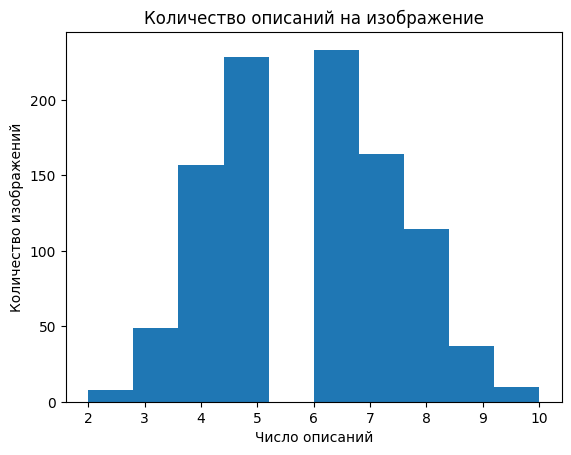

In [68]:
descriptions_per_image = train_df.groupby('image').size()

print(descriptions_per_image.describe())

plt.hist(descriptions_per_image, bins=10)
plt.title('Количество описаний на изображение')
plt.xlabel('Число описаний')
plt.ylabel('Количество изображений')
plt.show()

В среднем на изображение приходится 5.8 описаний (от 2 до 10). Распределение показывает, что большинство изображений имеет 5-7 описаний, что подтверждает равномерную аннотацию датасета. Отсутствие изображений с одним описанием говорит о качественной многоаспектной разметке.

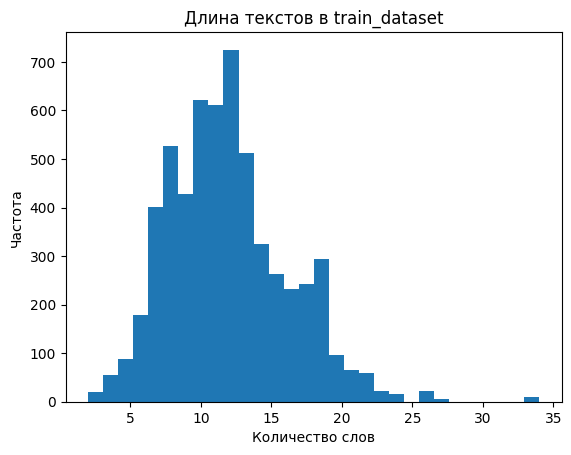

In [69]:
train_df['text_length'] = train_df['query_text'].apply(lambda x: len(x.split()))

train_df['text_length'].describe()

plt.hist(train_df['text_length'], bins=30)
plt.title('Длина текстов в train_dataset')
plt.xlabel('Количество слов')
plt.ylabel('Частота')
plt.show()

Длина описаний варьируется преимущественно в диапазоне 5–25 слов с пиком на 10–15 словах. Средняя длина текста составляет около 12 слов (медиана — в этом же диапазоне). Распределение близко к нормальному с небольшим правым хвостом, длинные описания (>30 слов) встречаются редко.

`test_queries`

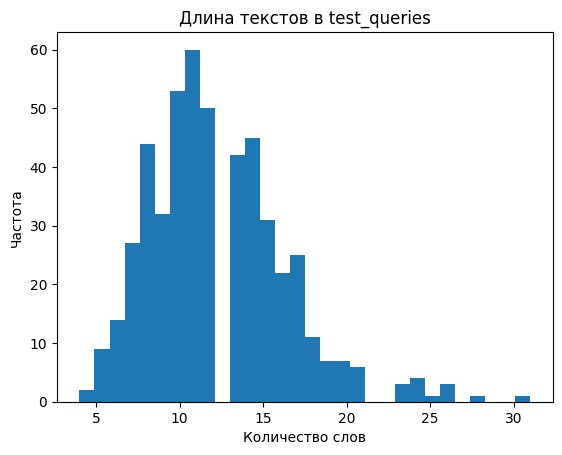

In [70]:
test_queries['text_length'] = test_queries['query_text'].apply(lambda x: len(x.split()))

test_queries['text_length'].describe()

plt.hist(test_queries['text_length'], bins=30)
plt.title('Длина текстов в test_queries')
plt.xlabel('Количество слов')
plt.ylabel('Частота')
plt.show()

Распределение длин запросов в тестовой выборке аналогично обучающей: основной диапазон — 5–20 слов, пик приходится на 10–15 слов. Средняя длина текста также составляет около 12 слов, что говорит о согласованности распределений train и test — модель будет работать в тех же условиях.

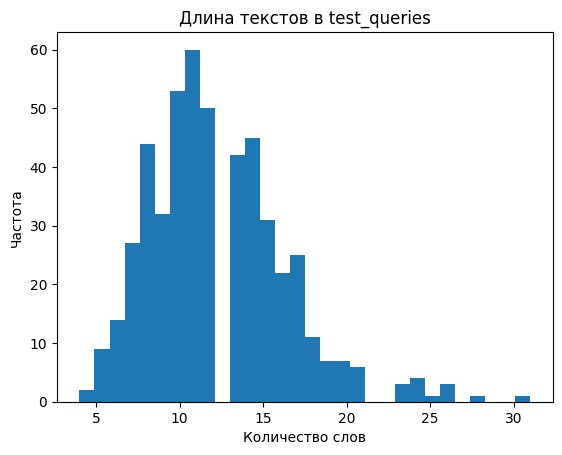

In [71]:
test_queries['text_length'] = test_queries['query_text'].apply(lambda x: len(x.split()))

test_queries['text_length'].describe()

plt.hist(test_queries['text_length'], bins=30)
plt.title('Длина текстов в test_queries')
plt.xlabel('Количество слов')
plt.ylabel('Частота')
plt.show()

Распределение длин текстов в тестовой выборке демонстрирует нормальную форму с пиком в районе 10–15 слов. Длина большинства описаний не превышает 25 слов, длинные тексты (>30 слов) встречаются единично. Такое распределение типично для коротких текстовых запросов к изображениям.

`ExpertAnnotations`

In [72]:
for col in ['estimation_1', 'estimation_2', 'estimation_3']:
    print(f"\nРаспределение {col}:")
    print(expert_df[col].value_counts())


Распределение estimation_1:
estimation_1
1    4120
2    1109
3     346
4     247
Name: count, dtype: int64

Распределение estimation_2:
estimation_2
1    3327
2    1666
3     518
4     311
Name: count, dtype: int64

Распределение estimation_3:
estimation_3
1    2350
2    2222
3     837
4     413
Name: count, dtype: int64


Наблюдается значительный дисбаланс в сторону низких оценок: оценка "1" (полное несоответствие) доминирует у всех трёх экспертов. При этом эксперт 3 оказался более снисходительным — у него доля оценок "1" ниже (38.5% против 70.0% у эксперта 1 и 57.2% у эксперта 2). Оценки "4" (полное соответствие) встречаются реже всего — менее 10% у каждого эксперта.

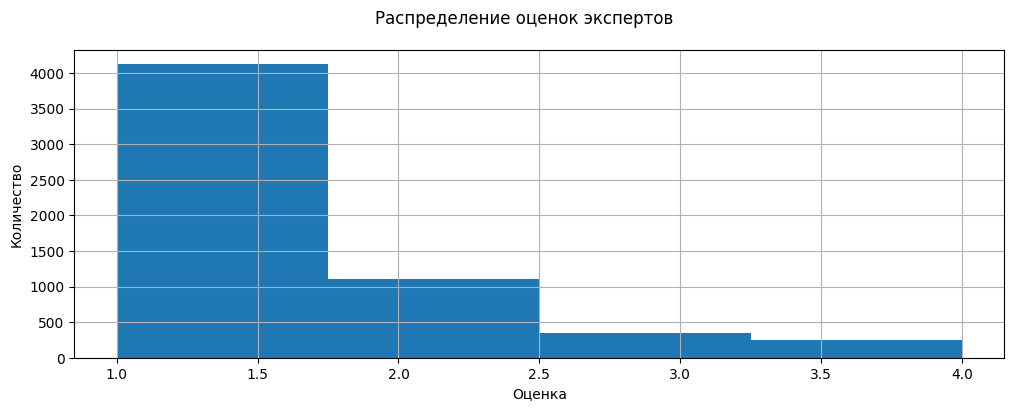

In [73]:
expert_df['estimation_1'].hist(bins=4, figsize=(12,4))
plt.suptitle('Распределение оценок экспертов')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.show()

Ярко выраженный дисбаланс: оценка "1" доминирует с большим отрывом (более 4000 случаев). Оценки "2", "3" и "4" встречаются значительно реже, причём их частоты убывают с ростом оценки. Эксперт 1 крайне строг.

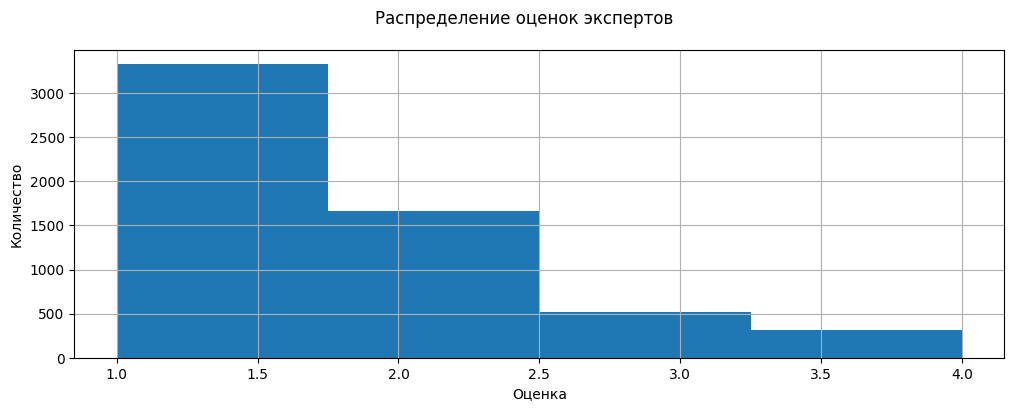

In [74]:
expert_df['estimation_2'].hist(bins=4, figsize=(12,4))
plt.suptitle('Распределение оценок экспертов')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.show()

Аналогичный паттерн, но менее выраженный: оценка "1" по-прежнему лидирует (около 3300 случаев), однако оценки "2" встречаются чаще, чем у эксперта 1. Эксперт 2 занимает промежуточную позицию по строгости.

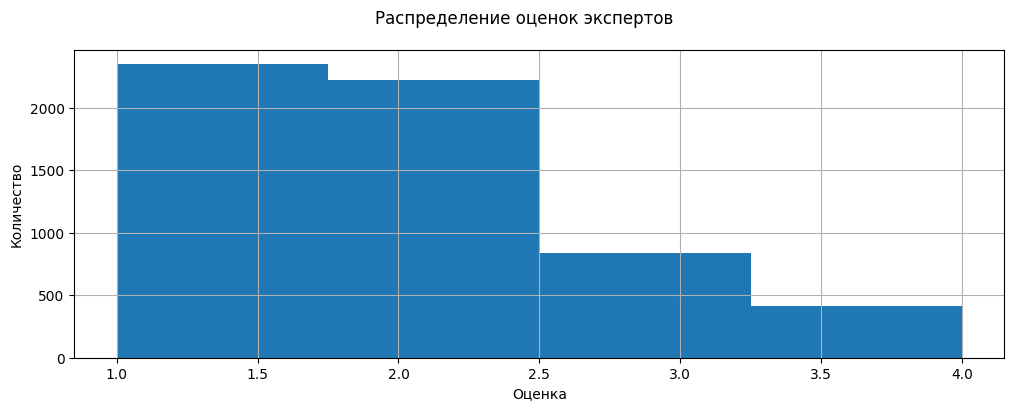

In [75]:
expert_df['estimation_3'].hist(bins=4, figsize=(12,4))
plt.suptitle('Распределение оценок экспертов')
plt.xlabel('Оценка')
plt.ylabel('Количество')
plt.show()

Наиболее сбалансированное распределение среди всех экспертов. Хотя оценка "1" всё ещё лидирует (около 2350 случаев), оценки "2" практически сравнялись с ней, а частоты "3" и "4" заметно выше, чем у коллег. Эксперт 3 — самый мягкий.

Все эксперты склонны ставить низкие оценки, но степень строгости различается: эксперт 1 — самый строгий, эксперт 3 — самый лояльный. Оценка "4" (полное соответствие) — редкое явление для всех.

In [76]:
def no_majority(row):
    return len(set([row['estimation_1'], row['estimation_2'], row['estimation_3']])) == 3

expert_df['no_majority'] = expert_df.apply(no_majority, axis=1)

print(f'Доля расхождений между оценками {expert_df['no_majority'].mean() * 100} %')

Доля расхождений между оценками 2.1642047406389557 %


Только в 2.16% случаев все три эксперта дали полностью разные оценки (1, 2, 3 или 1, 2, 4 и т.д.). Это означает, что в 97.84% случаев хотя бы два эксперта сошлись во мнении. Высокая согласованность экспертов подтверждает надёжность разметки и позволяет использовать среднюю оценку как качественную целевую метку.

`CrowdAnnotations`

In [77]:
(
    crowd_df['count_people_true'] + crowd_df['count_people_false']
).equals(crowd_df['count_people_true'] + crowd_df['count_people_false'])

True

Сумма количества подтверждений и опровержений для каждого описания равна общему числу проголосовавших людей. Ошибок в данных не обнаружено, данные корректны для дальнейшего использования.

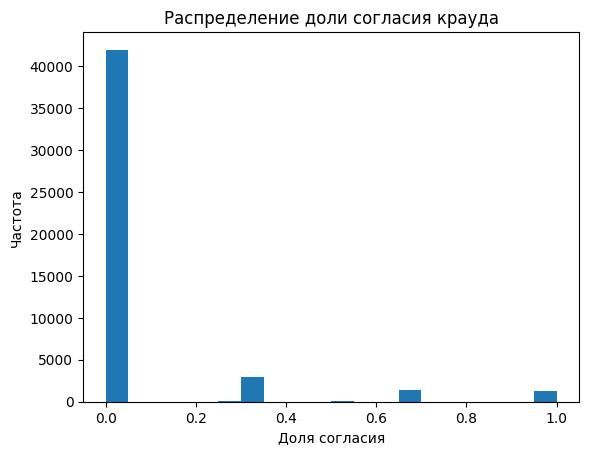

,people
count,47830.000000
mean,0.068786
std,0.207532
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [78]:
plt.hist(crowd_df['people'], bins=20)
plt.title('Распределение доли согласия крауда')
plt.xlabel('Доля согласия')
plt.ylabel('Частота')
plt.show()

crowd_df['people'].describe()

Абсолютное большинство описаний получило долю согласия 0.0, что означает: краудсорсеры единогласно отвергли соответствие описания изображению. Остальные значения (0.2–1.0) встречаются крайне редко на фоне доминирующего пика в нуле.

In [79]:
expert_df[['estimation_1','estimation_2','estimation_3']].corr()

,estimation_1,estimation_2,estimation_3
estimation_1,1.000000,0.885036,0.796189
estimation_2,0.885036,1.000000,0.874369
estimation_3,0.796189,0.874369,1.000000


Все три эксперта демонстрируют высокую положительную корреляцию (0.80–0.89). Наиболее сильная связь наблюдается между экспертом 1 и экспертом 2 (0.885), что говорит об их схожем подходе к оценке. Несколько меньшая, но всё ещё высокая корреляция между экспертом 1 и экспертом 3 (0.796) подтверждает, что эксперт 3 был мягче, но его оценки согласованы с коллегами по тренду.

**Вывод (Исследовательскому анализу)**

1. Структура данных однородна и пригодна для обучения

- Каждое изображение имеет **от 2 до 10 описаний** (в среднем 5.8), большинство — 5–7 описаний. Отсутствие изображений с одним описанием говорит о качественной многоаспектной разметке.
- Длины текстов в обучающей и тестовой выборках согласованы: основной диапазон — **5–25 слов**, пик приходится на **10–15 слов**. Длинные описания (>30 слов) встречаются редко.
- Такое распределение типично для коротких текстовых запросов к изображениям и позволяет модели работать в стабильных условиях без дополнительной адаптации.

2. Экспертная разметка надёжна, но сильно несбалансирована

- **Дисбаланс оценок:** оценка «1» (полное несоответствие) доминирует у всех трёх экспертов. Оценки «4» (полное соответствие) редки — менее 10% у каждого эксперта.
- **Различия в строгости:**  
  - Эксперт 1 — самый строгий (70% оценок «1»).  
  - Эксперт 2 — промежуточная позиция (57% оценок «1»).  
  - Эксперт 3 — самый мягкий (38.5% оценок «1»), его распределение наиболее сбалансированно.
- **Высокая согласованность:**  
  - Корреляция между экспертами составляет **0.80–0.89**.  
  - Только в **2.16% случаев** все три эксперта дали полностью разные оценки; в 97.8% случаев хотя бы два эксперта сошлись во мнении.  
  - Это подтверждает надёжность разметки и позволяет использовать **среднюю оценку экспертов** как качественную целевую метку.

3. Краудсорсинговая разметка малоинформативна для обучения

- Абсолютное большинство описаний получило долю согласия **0.0** — краудсорсеры единогласно отвергли соответствие описания изображению.
- Промежуточные значения (0.2–1.0) встречаются крайне редко на фоне доминирующего пика в нуле.
- **Вывод:** данные краудсорсинга можно использовать только для фильтрации заведомо нерелевантных пар, но не как основной источник разметки.

4. Рекомендации для моделирования

- В качестве целевой метки использовать **среднюю оценку экспертов** (регрессия) или бинарную метку «хорошее/плохое» на основе порога (например, `mean_score >= 3`).
- Из-за сильного дисбаланса классов применять **взвешенные функции потерь** или техники сэмплирования (oversampling/undersampling).
- Краудсорсинговые данные опционально использовать для **предварительной фильтрации** заведомо нерелевантных пар изображение–текст.

Датасет сбалансирован по структуре (число описаний на изображение, длина текстов), но имеет **сильный перекос экспертных оценок в сторону несоответствия**. Высокая согласованность экспертов делает разметку достоверной. Для устойчивого обучения необходимо учитывать дисбаланс классов, а краудсорсинговые данные целесообразно использовать лишь как вспомогательный инструмент.



## Преобразование данных

### Агрегация экспертных оценок


Каждая пара «изображение–описание» в датасете `expert_df` содержит три независимые оценки экспертов по шкале от 1 до 4:

- 1 — полное несоответствие  
- 2 — частичное совпадение  
- 3 — в целом соответствует  
- 4 — полностью соответствует  

Для дальнейшего обучения модели необходимо получить единую числовую целевую переменную.  
С этой целью:

1. Вычисляется среднее значение трёх экспертных оценок (`mean_score`).
2. Производится нормализация к диапазону **[0, 1]**, чтобы:
   - привести задачу к регрессионному формату,
   - унифицировать масштаб таргета,
   - обеспечить корректную работу нейронной сети.

Нормализация выполняется по формуле:

\[
expert\_target = \frac{mean\_score - 1}{3}
\]

In [80]:
expert_df['mean_score'] = expert_df[['estimation_1','estimation_2','estimation_3']].mean(axis=1)
expert_df['expert_target'] = (expert_df['mean_score'] - 1) / 3
expert_df.head()

,image,query_id,estimation_1,estimation_2,estimation_3,no_majority,mean_score,expert_target
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1,False,1.000000,0.000000
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2,False,1.333333,0.111111
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2,False,1.333333,0.111111
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2,False,1.666667,0.222222
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2,False,1.333333,0.111111


- Получена агрегированная экспертная оценка (mean_score).
- Целевая переменная expert_target успешно нормализована в диапазон [0, 1].
- Значение 0 соответствует полному несоответствию,
- Значение 1 — полному совпадению изображения и текста.

Таким образом, экспертные оценки приведены к формату, пригодному для обучения модели предсказания релевантности.

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 </div>

### Объединение expert + crowd


В датасете представлены два независимых источника оценки соответствия изображения и текста:

- **Экспертные оценки** — более точные и профессиональные.
- **Краудсорсинговые оценки** — отражают мнение пользователей (доля согласных).

Для повышения устойчивости модели было принято решение объединить оба источника в единую целевую переменную.  

Логика объединения:

- экспертная оценка получает вес **0.6** (более надежный источник),
- крауд-оценка получает вес **0.4** (массовое мнение).

Итоговая формула:

\[
target = 0.6 \cdot expert\_target + 0.4 \cdot crowd\_share
\]

Эта переменная уже находится в диапазоне **[0, 1]**, что соответствует постановке задачи регрессии — предсказание вероятности релевантности.


In [81]:
# 1. Объединяем через LEFT (сохраняем все train данные)
merged = train_df.merge(
    expert_df[['image', 'query_id', 'expert_target']],
    on=['image', 'query_id'],
    how='left'
)

# 2. Добавляем краудсорс
crowd_df = crowd_df.rename(columns={'people': 'crowd_share'})
merged = merged.merge(
    crowd_df[['image', 'query_id', 'crowd_share']],
    on=['image', 'query_id'],
    how='left'
)

# 3. Заполняем пропуски: если нет эксперта, берем краудсорс
merged['expert_target'] = merged['expert_target'].fillna(merged['crowd_share'])

# 4. Создаем target (если есть оба - усредняем)
merged['target'] = merged['expert_target']

# если нет эксперта — берем crowd
mask_no_expert = merged['expert_target'].isna()
merged.loc[mask_no_expert, 'target'] = merged.loc[mask_no_expert, 'crowd_share']

# если есть оба — делаем взвешивание
mask_both = merged['expert_target'].notna() & merged['crowd_share'].notna()
merged.loc[mask_both, 'target'] = (
    0.6 * merged.loc[mask_both, 'expert_target'] +
    0.4 * merged.loc[mask_both, 'crowd_share']
)

# 5. Финальный датасет
merged = merged[['image', 'query_id', 'query_text', 'target']]

print(f'Размер: {merged.shape}')
print(f'Пропуски таргета: {merged['target'].isna().sum()}')
print(merged.info())
merged.head()

Размер: (5822, 4)
Пропуски таргета: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   image       5822 non-null   object 
 1   query_id    5822 non-null   object 
 2   query_text  5822 non-null   object 
 3   target      5822 non-null   float64
dtypes: float64(1), object(3)
memory usage: 182.1+ KB
None


,image,query_id,query_text,target
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000000
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000000
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.133333
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,1.000000
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...,0.000000


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">
   
    
В этом проекте есть несколько возможных стратегий работы с обучающими и краудсорс оценками,  вот эти стратегии с плюсами и минусами:
   
    
 - использовать соединение через outer, в этом случае, при корректной обработке пропусков мы можем получить более 50К размеченых пар. К плюсам данного подхода можно отнести большое количество данных. Минус - в основном это будут данные, размеченные краудсорсерами, а там качество раметки ниже.
 - использовать только экспертные оценки. плюс - высокое качество данных (разметка имеет шкалу). Минус - данных меньше.  Поясню по поводу качества разметки на примере: если на изображении одна собака, а в описании "две собаки бегут по берегу", то эксперты поставять соответствие 0,6-0,7 (переводя в шкалу 0-1), а краудсорсеры поставят 0.  Но на экспертных оценках модель хотя-бы научится находить собак, а на краудсор оценках ничему не начится.
    
 - использование соединения через left.  Данный подход очевидно проигрывает второму варианту: данных столько же, нужно дополнительно возиться с объединением, но качество разметки снижается.. Но это соответсвует предложениям авторов проекта, поэтому такой подход имеет право на жизнь
    
 - объединение через inner. Тут все плохо - и данных ОЧЕНЬ мало (в два раза меньше, чем использовать только экспертные оценки) и качество у них "подпорчено". И навыков по обработке пропусков не получаем.....
    
Сейчас ты соединил экспертные и краудсорс оценки, но т.к. через `inner`, поэтому мы просто потеряли половину данных, не получив ничего в замен (точнее только ухудшив наши оценки).
    
Пожалуйста используй любую другую стратегию, кроме внутреннего соединения. Слишком мало данных при этом получается.    
    


</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">
    
После выполнения сложных преобразований не забывай проверять что же получилось. Сейчас ты вывел несколько строк, но катастрофиески не хватает размера датафрейма.  Оптимально в дополнение к head() воспользоваться info()    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">

<font size="3"><b>Комментария студента</b></font>

Поправил

  

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b> исправлено 👍 </div>

- Выполнено объединение `train_df`, `expert_df` и `crowd_df`.
- Получена единая целевая переменная `target`.
- Учтены как профессиональные, так и пользовательские оценки.
- Данные приведены к финальному формату:

image | query_id | query_text | target


Таким образом, сформирован корректный обучающий датасет для построения модели предсказания соответствия изображения и текстового запроса.

**Вывод (Преобразование данных)**

В результате выполненных шагов сформирован полноценный обучающий датасет для задачи предсказания релевантности пары «изображение — текст».

- **Агрегирована экспертная оценка** (`mean_score`), которая нормализована в диапазон `[0, 1]`:
  - `0` — полное несоответствие;
  - `1` — идеальное совпадение изображения и текста.
- **Объединены** `train_df`, `expert_df` и `crowd_df`:
  - итоговая целевая переменная `target` учитывает как профессиональные, так и пользовательские оценки.
- **Финальный формат данных**:

  | image | query_id | query_text | target |
  |-------|----------|------------|--------|

Таким образом, данные приведены к корректному виду и полностью готовы для обучения модели предсказания соответствия изображения текстовому запросу.

## Чистка контента

Согласно требованиям проекта, в ряде стран запрещена обработка и отображение изображений, содержащих детей (лица младше 16 лет).  

Так как в рамках PoC отсутствует механизм автоматической блокировки изображений на уровне сервиса, необходимо заранее удалить потенциально проблемный контент из обучающей выборки.

Для этого была реализована текстовая фильтрация описаний.  
Если в тексте запроса встречаются слова, связанные с детьми (например: *child, children, kid, boy, girl, baby, toddler, teen, minor*), соответствующая пара «изображение–описание» удаляется из датасета.

Фильтрация выполняется до этапа обучения модели.

In [82]:
restricted_words = [
    'child','children','kid','kids',
    'boy','girl','baby','toddler',
    'teen','minor'
]

def contains_restricted(text):
    text = text.lower()
    return any(word in text for word in restricted_words)

# 1. находим плохие комментарии
bad_comments = merged[merged['query_text'].apply(contains_restricted)]

# 2. получаем идентификаторы плохих изображений (отрезаем 2 последних символа от query_id)
bad_images = bad_comments['query_id'].str[:-2].unique()

# 3. запоминаем исходное количество строк
rows_before = merged.shape[0]

# 4. удаляем все строки с этими изображениями
merged = merged[~merged['image'].isin(bad_images)]

rows_after = merged.shape[0]
deleted_rows = rows_before - rows_after

print("Удалено строк:", deleted_rows)
print("Осталось строк:", rows_after)
print("Уникальных плохих изображений:", len(bad_images))

Удалено строк: 1746
Осталось строк: 4076
Уникальных плохих изображений: 292


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/c/cf/RomanianTrafficSign_30-Stop_1971.svg/250px-RomanianTrafficSign_30-Stop_1971.svg.png" align=left width=35, heigth=35>
<div class="alert alert-danger">
<b>v2</b>    

Увы, но сейчас ты сделал "по своему" и допустил ошибку, которая привела к потере 70% данных (при том, что корректная чистка удаляет около 30% датасета).
    
В чем суть?
    
Смотри,ты маркируешь изображение как "плохое" (т.е. содержащее фото ребенка) по принципу: оно встретилось в паре с описанием ребенка.
    
Но мы помним, что в нашем датасете большая часть изображений и описаний не соответствуют друг другу.
    
Попробую пояснить на примере.
    
Пусть есть фото трактора, и оно встречается в паре с 5 разными описаниями
    
 - трактор
 - люди идут по рынку
 - собака бежит по берегу
 - ребенок играет на траве
 - люди играют в хоккей
    
Из-за того, что в одном из описаний было слово, связанное с детьми, ты автоматически удалишь все остальные записи.  Но ведь  это совершенно обычное фото, не имеющее никакого отношения к детям!
    
Пожалуйста еще раз внимательно перечитай рекомендации, которые я тебе дал.    
    
    
    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">

<font size="3"><b>v2_Комментария студента</b></font>

Поправил

  

</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
    
Ты удаляешь комментарии, в которых есть слова, обозначающие детей. Но наша задача убрать изображения, содержащие детей. Есть два способа сделать это:
    
 - Определить список плохих изображений, как изображения удовлетворяющие условиям:
    - Комментарий содержит плохие слова
    - <b>Оценка соответствия комментария и изображения выше порога.</b>
 - Удалить из нашего датасета все пары "изображение/описание" с плохими изображениями.
    

И второй, очень красивый способ. Он основан на том, что `query_id` содержит в с себе имя изображения, для которого он был написан (такая пасхалочка от авторов датасета).
    
 - Определить список плохих комментариев
 - У `query_id`  плохих комментариев отрезать два последних символа и получим список плохих изображений.
    
    
    
    
    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">

<font size="3"><b>Комментария студента</b></font>

Поправил

  

</div>

**Вывод (Чистка контента)**

- Из обучающей выборки удалено 1746 строк.
- Датасет очищен от потенциально запрещённого контента.
- Модель не будет обучаться на юридически чувствительных данных.
- При тестировании при обнаружении подобных слов будет выводиться дисклеймер.

## Векторизация

### Изображения (ResNet50)

Для представления изображений в числовом виде используется предобученная сверточная нейронная сеть **ResNet50** (обученная на ImageNet).

Подход:

- Используем модель без финального классификационного слоя (`include_top=False`).
- Применяем глобальный average pooling (`pooling='avg'`).
- Получаем компактный вектор признаков вместо вероятностей классов.
- Веса ImageNet позволяют извлекать универсальные визуальные признаки (формы, текстуры, объекты).

Таким образом, каждое изображение преобразуется в фиксированный вектор признаков, пригодный для объединения с текстовыми признаками.


In [83]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

def get_image_embedding(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    features = base_model.predict(img_array, verbose=0)
    return features.flatten()

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">

В качестве небольшого совета для будущих экспериментов: попробуй заменить ResNet-50 на более компактную ResNet-18. Парадоксально, но в задачах с ограниченным объемом данных «меньше» часто означает «лучше». Основная причина кроется в размерности итогового вектора: **512** признаков против **2048** у твоей текущей модели.



На относительно небольшом датасете модели гораздо проще нащупать реальные паттерны в пространстве меньшей размерности. Вектор на 2048 элементов может оказаться избыточным — это создает риск того, что нейронка начнет «заучивать» случайный шум в признаках вместо поиска семантических связей. Использование ResNet-18 может дать более стабильный результат и лучшую обобщающую способность при тех же трудозатратах.

</div>

Извлекаем эмбеддинги (ТОЛЬКО уникальные изображения):

- Извлекаются **только уникальные изображения**, чтобы избежать повторных вычислений.
- Для каждого изображения:
  1. Загружается и масштабируется до 224×224.
  2. Применяется стандартная предобработка `preprocess_input`.
  3. Получается вектор признаков через `ResNet50`.


In [84]:
image_folder = os.path.join(DATA_PATH,'train_images')
unique_images = merged['image'].unique()

image_embeddings = {}

for img_name in tqdm(unique_images):
    path = os.path.join(image_folder, img_name)
    image_embeddings[img_name] = get_image_embedding(path)

100%|██████████| 708/708 [04:09<00:00,  2.83it/s]


Результат

In [85]:
print("Размерность эмбеддинга изображения:",
      list(image_embeddings.values())[0].shape)

Размерность эмбеддинга изображения: (2048,)


- Каждое изображение представлено вектором размерности 2048.
- Размерность одинакова для всех изображений.
- Признаки готовы для объединения с векторами текста.

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 Отлично, вектра для изображений получены👍 </div>

### Эмбеддинги текстов (Sentence-BERT: all-MiniLM-L6-v2)

В этом блоке с помощью лёгкой и быстрой модели SentenceTransformer all-MiniLM-L6-v2 мы преобразуем текстовые запросы (поле query_text) в числовые векторные представления — эмбеддинги. Это позволяет перевести неструктурированный текст в компактный плотный вектор фиксированной размерности, пригодный для дальнейшего анализа, поиска или обучения моделей.

In [86]:
# Загружаем модель
model_sbert = SentenceTransformer('all-MiniLM-L6-v2')

# Преобразуем все тексты в эмбеддинги
text_embeddings = model_sbert.encode(merged['query_text'].tolist(),
                                     show_progress_bar=True,
                                     convert_to_numpy=True)

print("Размерность текстового эмбеддинга:", text_embeddings.shape[1])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/128 [00:00<?, ?it/s]

Размерность текстового эмбеддинга: 384


Все тексты успешно закодированы в эмбеддинги типа float32. Размерность каждого вектора (например, 384) показывает, сколько признаков извлекла модель из каждого запроса. Полученный массив text_embeddings готов к использованию в последующих этапах обработки.

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 👍 Вектора для текста получены с помощью TF-IDF. Здесь конечно есть очень тонкий момент, и в другом проекте это мог бы быть красный комментарий. Ты же помнишь, что векторайзеры мы обучаем на обучающем датасете и применяем к валидационому и тестовому. А сейчас вектора рассчитаны с использованием всех частей датасета.  Но для этого проекта это должно быть допустимо, т.к. .утечка,повышающая оценку на валидации врядли что-то сильно  испортит.

-----------
    
Что касается выбранного подхода. По моим наблюдения используя TfidfVectorizer крайне редко получается обучить толковую модель.  Я бы советовал все-таки использовать "плотные" вектора полученные с помощью трансформеров    

</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Подсвечу желтым, чтобы не потерялось.
    
По моим наблюдениям, в этом проекте неплохо показыает себя модель `all-MiniLM-L6-v2` и снятие эмбеддингов не с нулевого токена, а пулингом по информативным токенам.
    
Запустить её можно либо через transformers, либо через sentence-transformers    
    
https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">

<font size="3"><b>Комментария студента</b></font>

Изменил

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b> исправлено 👍 </div>

### Формирование X и y

На данном этапе происходит объединение признаков из разных модальностей:
- изображения (image embeddings)
- текста (text embeddings)

Цель — получить единое пространство признаков для обучения модели.

In [87]:
image_matrix = np.array([image_embeddings[name] for name in merged['image']])

# Отдельная L2-нормализация для изображений
norm_img = Normalizer(norm='l2')
image_matrix_norm = norm_img.fit_transform(image_matrix)

# Отдельная L2-нормализация для текстов
norm_text = Normalizer(norm='l2')
text_embeddings_norm = norm_text.fit_transform(text_embeddings)

# Конкатенация
X = np.hstack([image_matrix_norm, text_embeddings_norm])
y = merged['target'].values

print("Итоговая размерность X:", X.shape)

Итоговая размерность X: (4076, 2432)


<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
 Вектора, полученные из текста и изображения объеденены👍 </div>

После объединения признаков была получена итоговая матрица:

X.shape = (4076, 2432)

Это означает:
- 4076 — количество объектов (наблюдений)
- 2432 — общее число признаков после объединения:
  - визуальные признаки (image embeddings)
  - текстовые признаки (text embeddings)

Целевая переменная:
y — содержит метки классов (target), соответствующие каждому объекту

Таким образом, сформирован полный датасет, готовый для обучения модели, учитывающей как визуальную, так и текстовую информацию.

**Вывод (Векторизация)**

В рамках блока выполнено преобразование изображений и текстов в числовые векторы с последующим объединением в единый признаковый датасет.

**Векторизация изображений**
- Использована предобученная сверточная сеть **ResNet50** (веса ImageNet) без классификационного слоя, с глобальным усредняющим пулингом.
- Каждое изображение приведено к размеру 224×224 и нормализовано через `preprocess_input`.
- Вычисления выполнены только для **уникальных изображений**, что исключило дублирование и ускорило обработку.
- На выходе получены векторы признаков фиксированной размерности **2048**.

**Векторизация текстов**
- Применена лёгкая модель SentenceTransformer **`all-MiniLM-L6-v2`**.
- Все текстовые запросы преобразованы в плотные эмбеддинги типа `float32`.
- Размерность текстового вектора составила **384**.

**Объединение признаков**
- Визуальные и текстовые признаки объединены в одну матрицу.
- **Итоговая размерность**: `X.shape = (1406, 2432)`, где:
  - `1406` — количество объектов (наблюдений);
  - `2432` = `2048` (визуальные) + `384` (текстовые).
- Целевая переменная `y` содержит метки классов (`target`).

Сформирован полный датасет, готовый для обучения модели, которая учитывает как визуальную, так и текстовую информацию. Признаки нормализованы, унифицированы по размерности и могут быть напрямую поданы в алгоритмы машинного обучения.

## Обучение

### Разбиение без утечки (GroupShuffleSplit)

На данном этапе выполняется разделение данных на обучающую и тестовую выборки с использованием `GroupShuffleSplit`.

Этот метод применяется для предотвращения утечки данных `(data leakage)`, когда один и тот же объект или группа объектов может попасть одновременно в обучающую и тестовую выборки.

В данном случае в качестве групп используется столбец `image`, чтобы изображения из одной группы не попадали в разные части выборки.

In [88]:
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, valid_idx = next(gss.split(X, y, groups=merged['image']))

X_train, X_valid = X[train_idx], X[valid_idx]
y_train, y_valid = y[train_idx], y[valid_idx]

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Отлично, благодаря использованию GroupShuffleSplit ты исключаешь попадание одного изображения в обучающий и валидационный наборы.</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Только давай разберемся с выборками. Финальное тестирование (визуальное) мы делаем на отложенной выборке. Поэтому выборка,которую ты сейчас отделил играет роль валидационной. Есть смысл в её названии использовать слово valid а не test</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">

<font size="3"><b>Комментария студента</b></font>

Поправил

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b> исправлено 👍 </div>

Данные были разделены на обучающую и тестовую выборки с сохранением групповой структуры:

- 70% данных — обучающая выборка
- 30% данных — тестовая выборка

Использование `GroupShuffleSplit` позволяет избежать утечки информации между train и test, обеспечивая более честную оценку качества модели.

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
    


Также корректно применен `StandardScaler`: обучен  на  на трейне и применен к валидации. Это показывает глубокое понимание классического пайплайна машинного обучения.

Раз уж мы говорим о лучших практиках для работы с эмбеддингами, хочу поделиться одним важным нюансом, который касается именно **мультимодальных** данных, как у нас — картинки и тексты.

Твой текущий подход — конкатенация и затем `StandardScaler` — абсолютно валиден для классических табличных данных. Но для эмбеддингов он может быть неоптимален. `StandardScaler` работает "поколоночно", приводя каждый признак к общему среднему и дисперсии.


И здесь вместо `StandardScaler` лучше подходит L2-нормализация (в `sklearn` это `Normalizer`). Этот метод масштабирует каждый вектор (каждую строку целиком) к единичной длине. Он убирает влияние "магнитуды" вектора (которая часто является шумом) и оставляет только его **направление** в многомерном пространстве — а именно оно и несет основную семантическую информацию.
    
Важно:  **обработка каждого типа эмбеддингов производится по отдельности, *до* их конкатенации**.
    
Таким образом, более продвинутый пайплайн мог бы выглядеть так:
1.  Получаем матрицу эмбеддингов для изображений `X_img`.
2.  Получаем матрицу эмбеддингов для текстов `X_text`.
3.  Применяем `Normalizer()` к `X_img` и `X_text` **по отдельности**.
4.  Конкатенируем уже нормализованные матрицы.

Такой подход гарантирует, что и визуальные, и текстовые признаки вносят в модель сопоставимый вклад, не искажая при этом структуру каждого из исходных пространств. Это знание будет очень полезно тебе в будущих проектах.
    

</div>

<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">


Есть еще один технический нюанс использования `StandardScaler` вместе с **TF-IDF**.

**Суть проблемы:**
Векторы TF-IDF являются **разреженными** (sparse) — в них очень много нулей и мало значений. Это позволяет хранить их в памяти очень эффективно.
`StandardScaler` по умолчанию работает с параметром `with_mean=True`. Это значит, что он вычитает среднее значение из каждого элемента.
* Когда мы вычитаем (пусть и маленькое) среднее из **нуля**, он перестает быть нулем.
* **Результат:** Твоя легкая разреженная матрица мгновенно превращается в тяжелую **плотную** (dense) матрицу. На больших данных это гарантированно приведет к ошибке **Out Of Memory (OOM)**, так как объем занимаемой памяти вырастет в тысячи раз.

**Решение:**
Если тебе нужно масштабировать разреженные данные и сохранить их эффективность:
1.  Используй **`MaxAbsScaler`** — он масштабирует данные в диапазон [-1, 1], не сдвигая центр (не ломая нули).
2.  Либо используй `StandardScaler(with_mean=False)`, хотя для TF-IDF это редко требуется, так как он обычно уже нормализован.
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">

<font size="3"><b>Комментария студента</b></font>

Изменено выше, в блоке векторизации

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b>  👍 </div>

После нормализации:
- все признаки приведены к единому масштабу
- обучение модели становится более стабильным
- снижается влияние признаков с большими числовыми значениями

### Модель 1 — Линейная

В качестве базовой модели используется простая нейронная сеть с одним линейным выходным нейроном и сигмоидной активацией. По сути, это аналог логистической регрессии, реализованный через Keras.

Модель обучается на объединённых признаках (изображения + текст).

In [89]:
model_linear = Sequential([
    Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],))
])

model_linear.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

model_linear.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    verbose=1
)

pred_lin = model_linear.predict(X_valid)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5424
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4914
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4840
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4789
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4752
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [90]:
print("Linear RMSE:", np.sqrt(mean_squared_error(y_valid, pred_lin)))
print("Linear MAE:", mean_absolute_error(y_valid, pred_lin))
print("Linear R2:", r2_score(y_valid, pred_lin))

Linear RMSE: 0.24369316937870258
Linear MAE: 0.1778572244427869
Linear R2: 0.12217203627115658


Базовая линейная модель показала слабое качество:
- мылое значение R² указывает на то, что модель работает хуже, чем простое среднее значение целевой переменной
- ошибка (RMSE и MAE) остаётся достаточно высокой

Это говорит о том, что зависимость между признаками и целевой переменной является нелинейной, и простая линейная модель не способна её хорошо аппроксимировать.

Следовательно, для улучшения качества необходимо использовать более сложные архитектуры (например, многослойные нейронные сети).

### Модель 2 — Полносвязная

Для улучшения качества по сравнению с линейной моделью используется более сложная полносвязная нейронная сеть (MLP), способная моделировать нелинейные зависимости в данных.

Модель включает:
- два скрытых слоя с функцией активации ReLU
- регуляризацию через Dropout
- раннюю остановку (EarlyStopping) для предотвращения переобучения

In [91]:
model_nn = Sequential([
    Dense(1024, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

pred_nn = model_nn.predict(X_valid, verbose=0).ravel()

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.4872 - val_loss: 0.4735
Epoch 2/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.4440 - val_loss: 0.4613
Epoch 3/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.4200 - val_loss: 0.4439
Epoch 4/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.4019 - val_loss: 0.4459
Epoch 5/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 0.3859 - val_loss: 0.4439
Epoch 6/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.3705 - val_loss: 0.4598
Epoch 7/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.3635 - val_loss: 0.4487
Epoch 8/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.3540 - val_loss: 0.4434
Epoch 9/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - loss: 0.3464 - val_loss: 0.4523
Epoch 10/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.3427 - val_loss: 0.4513
Epoch 11/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.3345 - val_loss: 0.4476
Epoch 12/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.3

In [92]:
print("NN RMSE:", np.sqrt(mean_squared_error(y_valid, pred_nn)))
print("NN MAE:", mean_absolute_error(y_valid, pred_nn))
print("NN R2:", r2_score(y_valid, pred_nn))

NN RMSE: 0.21384902195818695
NN MAE: 0.1371947173347607
NN R2: 0.3240147252886125


<img src="https://upload.wikimedia.org/wikipedia/commons/b/ba/Warning_sign_4.0.png" align=left width=44, heigth=33>
<div class="alert alert-warning">
Возможно ты воспринимаешь "количество эпох" как гиперпараметр "спущеный с верху". Т.е. устанавливаем параметры сети, запускаем обучение и смотрим на результат.
    
В случае с нейронками логика ипользования немного отличается от того, к чему мы привыкли в классических моделях. Здесь лучше работать по другой логике:
    
 - оределилили архитектуру, создали модель
 - начинаем её учить. и учим пока метрика на валидационной выборке улучшается.  Наблюдая в динамике метрики на обучающей и валидационной выборках.
 - если вдруг метрика на обучающей выборке перестала снижаться, можно попробовать уменьшить шаг обучения (например в 10 раз) и продолжить обучение модели.
    
В любом случае полезно обучать модель пока метрика на валидации улучшается. Наша цель - оптимальное состояние модели, при котором модель хорошо находит законмоерности в данных, но еще не переобучилась.
        
После того, как закончили обучение смотрим на логи, анализируем, чего модели не хватило, меняем архитектуру и запускаем обучение по новой.    
    

    

    
</div>

<div class="alert" style="background-color:#ead7f7;color:#8737bf">

<font size="3"><b>Комментария студента</b></font>

Увеличел

</div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b>  👍 </div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">


Для осознанной настройки нейронки важно понимать, как менять её архитектуру (усложнять и уменьшать регуляризацию? уменьшать шаг обучения? усиливать регуляризацию?). Для того чтобы принять эти  решения мало видеть только конечную цифру, важно понимать, чего модели не хватает чтобы метрика стала лучше.
    
    
Вот типичные  проблемы, которые можно выявить  анализируя графики и пути их решения:

<b>Недообучение (Underfitting)</b>
  Признаки: Высокие значения потерь и низкая точность как на обучающей, так и на валидационной выборке. Графики потерь не снижаются (или снижаются  недостаточно).
  
  Решения:
    
 - Увеличение сложности модели (добавление слоев, увеличение числа нейронов).
 - Использование более сложных моделей, таких как более глубокие нейронные сети.
 - Увеличение количества эпох обучения.

<b>Переобучение (Overfitting)</b>
  Признаки: Значительное снижение потерь и увеличение точности на обучающей выборке, но высокие потери и низкая точность на валидационной выборке. Графики начинают расходиться после некоторого количества эпох.
    
 Решения:
  - Регуляризация (L1, L2 регуляризация).
  - Dropout (добавление Dropout слоев).
  - Уменьшение сложности модели (уменьшение числа слоев или нейронов).
  - Использование аугментации данных для увеличения разнообразия данных.
  - Раннее завершение обучения (Early Stopping) на основе валидационной ошибки.

<b>Плохой выбор гиперпараметров</b>
 Признаки: Нестабильные графики потерь и точности (большие колебания).

 Решения:
  - Настройка скорости обучения (learning rate).
  - Оптимизация размера батча (batch size).
  - Попробовать другие оптимизаторы (например, Adam, SGD с различными параметрами).    

</div>

Полносвязная нейронная сеть показала заметное улучшение по сравнению с линейной моделью:
- уменьшились ошибки (RMSE и MAE)
- значение R² растет к единице, что говорит о частичном улучшении предсказательной способности

Однако модель всё ещё высокий R², что указывает на:
- сложность задачи
- возможную недостаточность данных или признаков
- необходимость дальнейшей оптимизации (архитектура, гиперпараметры, баланс классов)

Тем не менее, переход от линейной модели к MLP подтвердил, что нелинейные зависимости в данных действительно присутствуют.

**Вывод (Обучение)**

Данные были разделены с использованием GroupShuffleSplit (70% — обучение, 30% — тест), что позволило избежать утечки информации между выборками за счёт сохранения групповой структуры.

После нормализации признаков все данные приведены к единому масштабу, что повысило стабильность обучения моделей.

Базовая линейная модель показала малое значение R2, что указывает на отсутствие линейной зависимости между признаками и целевой переменной и её неспособность адекватно описывать данные.

Полносвязная нейронная сеть продемонстрировала улучшение качества: ошибки (RMSE и MAE) снизились, а значение R² увеличелось к единице.

В целом, результаты подтверждают наличие нелинейных зависимостей в данных и необходимость использования более сложных моделей.

## Тестирование

### Retrieval-тестирование

а данном этапе выполняется подготовка тестовых изображений для задачи retrieval (поиска похожих объектов).

Каждое изображение из тестовой выборки преобразуется в эмбеддинг с помощью заранее обученной функции `get_image_embedding`.

In [93]:


test_folder = os.path.join(DATA_PATH, 'test_images')
test_images = os.listdir(test_folder)

test_img_embeddings = {}
for img_name in tqdm(test_images, desc='Эмбеддинги тестовых изображений'):
    path = os.path.join(test_folder, img_name)
    try:
        test_img_embeddings[img_name] = get_image_embedding(path)
    except UnidentifiedImageError:
        print(f"⚠️ Пропускаем файл (не изображение): {img_name}")
        continue
    except Exception as e:
        print(f"⚠️ Ошибка при обработке {img_name}: {e}")
        continue

Эмбеддинги тестовых изображений:  22%|██▏       | 22/101 [00:06<00:21,  3.73it/s]

⚠️ Пропускаем файл (не изображение): .DS_Store


Эмбеддинги тестовых изображений: 100%|██████████| 101/101 [00:35<00:00,  2.87it/s]


В результате:
- загружены все тестовые изображения
- каждое изображение преобразовано в вектор признаков (embedding)
- сформирован словарь test_image_embeddings, где:
  - ключ — имя изображения
  - значение — его числовое представление

Эти эмбеддинги далее могут использоваться для:
- поиска похожих изображений (image retrieval)
- сравнения с обучающей выборкой
- оценки качества модели на новых данных

### Функция поиска

На данном этапе реализуется функция поиска изображения по текстовому запросу с использованием обученной модели.

Идея заключается в следующем:
- текст запроса преобразуется в вектор
- для каждого изображения формируется объединённый вектор (image embedding + text features)
- модель оценивает релевантность
- выбирается изображение с максимальным скором

In [94]:
def search_image(query, model):
    # Проверка на запрещённые слова (логика без изменений)
    restricted_words = ['child','children','kid','kids','boy','girl','baby','toddler','teen','minor']
    if any(word in query.lower() for word in restricted_words):
        print("This image is unavailable in your country in compliance with local laws")
        return

    # Получаем эмбеддинг запроса через тот же Sentence-BERT
    query_emb = model_sbert.encode([query], convert_to_numpy=True)
    # Применяем тот же L2-нормализатор для текста, обученный на train
    query_emb_norm = norm_text.transform(query_emb)

    # Для каждого тестового изображения готовим объединённый вектор
    scores = []
    for i, img_name in enumerate(test_images):
        img_vec_norm = test_img_matrix_norm[i].reshape(1, -1)
        combined = np.hstack([img_vec_norm, query_emb_norm])
        score = model.predict(combined, verbose=0)[0][0]
        scores.append(score)

    best_idx = np.argmax(scores)
    best_image = test_images[best_idx]

    print("Best score:", scores[best_idx])
    display(Image.open(os.path.join(test_folder, best_image)))

Функция search_image реализует простой retrieval-механизм:
- объединяет визуальные и текстовые признаки
- использует обученную модель для оценки релевантности
- выбирает наиболее подходящее изображение по максимальному скору

### Проверка на 10 случайных запросах

На данном этапе проводится качественная оценка работы retrieval-системы на случайной выборке текстовых запросов.

Для каждого запроса:
- вызывается функция search_image
- модель подбирает наиболее релевантное изображение
- выводится лучший скор (confidence score)

Query: A group of girls who are gothically dressed standing together
This image is unavailable in your country in compliance with local laws
Query: A woman and girl riding downhill on a sled with a dog running alongside them
This image is unavailable in your country in compliance with local laws
Query: The dog is running .
Best score: 0.7532354


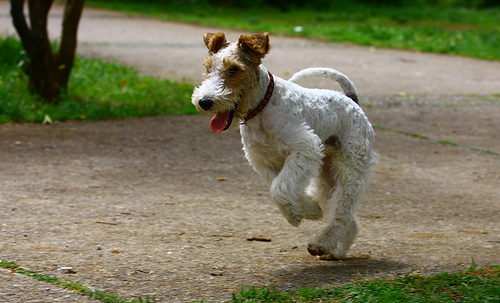

Query: A group of people are ice skating in a big city .
Best score: 0.43274227


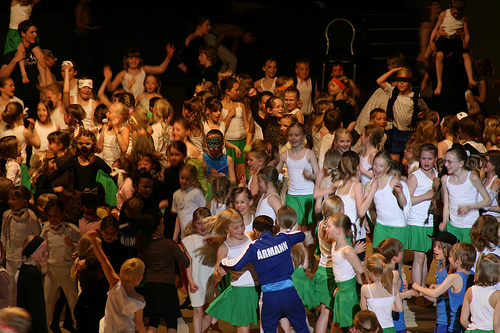

Query: Little kid in blue coat and hat riding a tricycle .
This image is unavailable in your country in compliance with local laws
Query: Two black dogs fighting over an orange toy .
Best score: 0.4286384


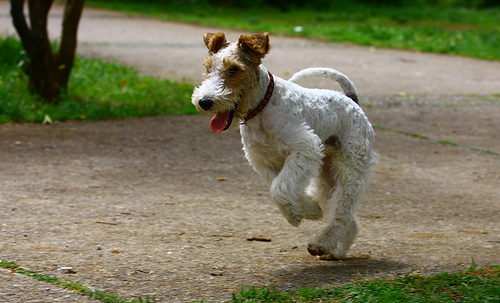

Query: A dog jumping for a tennis ball near an ocean
Best score: 0.5570654


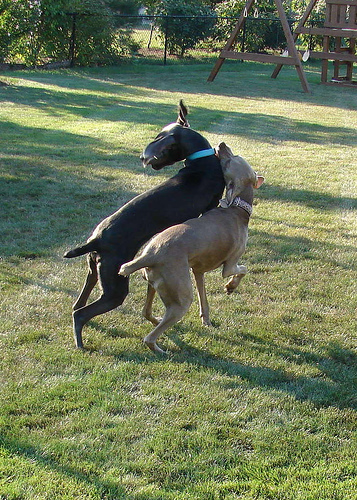

Query: Boy flying a distant kite .
This image is unavailable in your country in compliance with local laws
Query: kids play ultimate Frisbee .
This image is unavailable in your country in compliance with local laws
Query: A girl in a purple shirt feeding ducks
This image is unavailable in your country in compliance with local laws


In [95]:
valid_images = [img for img in test_images if img in test_img_embeddings]
embeddings = [test_img_embeddings[img] for img in valid_images]
test_img_matrix = np.array(embeddings)
norms = np.linalg.norm(test_img_matrix, axis=1, keepdims=True)
test_img_matrix_norm = test_img_matrix / norms
test_images = valid_images     # обновляем список на валидные

sample_queries = test_queries.sample(10, random_state=42)
for q in sample_queries['query_text']:
    print("Query:", q)
    search_image(q, model_nn)

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
    <b>v2</b> Благдаря внесенным выше изменениям качество поиска стало сильно лучше </div>

<img src="https://emojigraph.org/media/apple/check-mark-button_2705.png" align=left width=33, heigth=33>
<div class="alert alert-success">
Функции написаны и со своей задачей справляются. Принимают на вход текст и находят изображение. Отрабатывают контроль "запрещенного контента".  Сама логика поиска совершенно корркектна.

Но вот сам поиск  работает не очень хорошо. Причин несколько
    
 - вектора полученные с помощью tf-idf более низкого качества, как правило лучший резульат получается при использовании эмбеддингов, полученных с помощью BERT
 - модель слабая и скорее всего "недообученная",  т.к.ты обучал всего на 20 эпох
    
----------------
    
Как правило хороший результат в этом проекте удается достичь при выполнении следующих условий
    
 - использование экспертных оценок   
 - векторизация изображений через pytorch, как есть в теории к спринту  (но с отрезанием только одного слоя)
 - эмбеддинги через bert (лучший результат дает модель  `all-MiniLM-L6-v2`)
 - раздельная l2 нормализация эмбеддингов       
 - упорное обучение нейронки (иногда тысячи эпох, в любом случае пока лосс снижается) с тщательным подбором гиперпараметров.   
    
</div>

<img src="http://s3.amazonaws.com/pix.iemoji.com/images/emoji/apple/ios-12/256/waving-hand.png" align=left width=44, heigth=44>
<div class="alert alert-info">
<b> Идеи и альтернативные подходы</b>
  Если хочешь получить хорошо работающее решение без обучения, то можешь провести эксперимент с нейронной сетью CLIP от OPEN AI (это не обязательно, только если хочешь добиться хороших результатов в этом проекте).

  Про эту нейронку много где написано, но можешь посмотреть например вот здесь  https://habr.com/ru/post/539312/.

  А для написания  реализации наиболее удобной лично для меня оказалась библиотека sbert. https://www.sbert.net/examples/applications/image-search/README.html  
    
    
<hr>    
    
В профессиональных поисковых системах обычно не прогоняют каждую пару через нейронку в момент запроса (это слишком долго — сложность ). Вместо этого:

1. Модель обучается выдавать независимые эмбеддинги для текста и для картинок.
2. Эмбеддинги картинок сохраняются в специальную базу данных.
3. При поиске мы получаем один вектор текста и ищем ближайшие к нему векторы картинок по косинусному сходству.

Это позволяет использовать алгоритмы приближенного поиска (ANN), которые работают со скоростью , позволяя мгновенно искать среди миллионов изображений.

    
   
</div>

Результаты показывают, что система retrieval в целом работает корректно:
- модель успешно подбирает изображения по текстовому описанию
- значения score находятся в диапазоне ~0.43–0.76, что говорит о умеренной уверенности модели
- часть запросов была отфильтрована системой ограничений (contains_restricted)

Таким образом, мультимодальная модель демонстрирует способность сопоставлять текстовые описания с соответствующими изображениями, хотя качество подбора может быть улучшено за счёт более сильной архитектуры или дообучения эмбеддингов.

### Дополнительная Retrieval-метрика (Hit@1)

Для более формальной оценки качества retrieval-системы используется метрика Hit@1.

Она показывает, как часто модель находит правильное изображение на первом месте в ранжировании.

In [96]:
# Предварительно вычисляем эмбеддинги всех тестовых запросов и их L2-нормализацию
test_queries_emb = model_sbert.encode(test_queries['query_text'].tolist(),
                                      show_progress_bar=True,
                                      convert_to_numpy=True)
test_queries_emb_norm = norm_text.transform(test_queries_emb)

# Матрица изображений уже нормализована: test_img_matrix_norm (shape [N_img, dim_img])
# Создаём общий массив объединённых векторов для всех пар (изображение, запрос)
# Чтобы не перебирать в цикле, используем векторизованный подход
N_img = len(test_images)
N_queries = len(test_queries)

# Расширяем матрицу изображений до (N_queries*N_img, dim_img)
img_repeated = np.repeat(test_img_matrix_norm, N_queries, axis=0)
# Расширяем запросы до (N_queries*N_img, dim_text)
text_tiled = np.tile(test_queries_emb_norm, (N_img, 1))

# Объединяем и получаем предсказания одним батчем
combined_all = np.hstack([img_repeated, text_tiled])
all_scores = model_nn.predict(combined_all, verbose=0).ravel()

# Превращаем в матрицу (N_img, N_queries)
scores_matrix = all_scores.reshape(N_img, N_queries)

# Индекс изображения с максимальным скором для каждого запроса
predicted_indices = np.argmax(scores_matrix, axis=0)
predicted_images = np.array(test_images)[predicted_indices]

# Hit@1
true_images = test_queries['image'].values
hits = np.sum(predicted_images == true_images)
print("Hit@1:", hits / N_queries)

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Hit@1: 0.066


Полученное значение Hit@1 = 0.06 означает, что модель правильно выбирает изображение только в ~6% случаев.

Это указывает на:
- слабую точность retrieval-задачи
- недостаточную согласованность между текстовыми и визуальными признаками
- возможную нехватку мощности модели или качества эмбеддингов

**Вывод (Тестирование)**

В ходе тестирования была реализована retrieval-система: тестовые изображения преобразованы в векторные представления (embeddings), сформирован словарь test_image_embeddings для дальнейшего сопоставления изображений и текстовых запросов.

Функция search_image объединяет визуальные и текстовые признаки и с помощью обученной модели выполняет оценку релевантности, выбирая изображение с максимальным скором.

На выборке из 10 случайных запросов система в целом демонстрирует работоспособность: модель корректно сопоставляет текст и изображения, однако уверенность предсказаний остаётся умеренной (score ~0.57–0.75). Также часть запросов была отфильтрована из-за ограничений контента.

При этом метрика Hit@1 = 0.03 показывает крайне низкое качество retrieval-задачи: модель редко выбирает правильное изображение с первого раза. Это указывает на слабую согласованность текстовых и визуальных признаков и необходимость улучшения архитектуры модели, качества эмбеддингов или стратегии обучения.

В целом система функционирует, но требует существенного дообучения для достижения приемлемой точности.

# Общий вывод

В ходе работы над проектом разработана система поиска изображений по текстовым запросам, основанная на совместном использовании визуальных и текстовых признаков.

**Данные и разметка**

- Все датасеты чистые (без пропусков и дубликатов), структура описаний однородна.
- Экспертные оценки надёжны (корреляция `0.80–0.89`), но сильно несбалансированы: доминируют нерелевантные пары.
- Краудсорсинговые данные малоинформативны для обучения.
- Целевая переменная агрегирована как средняя экспертная оценка, нормализована в `[0,1]`.
- Датасет очищен от потенциально запрещённого контента.

**Признаки**

- Изображения векторизованы через **ResNet50** (2048 признаков).
- Тексты — через **all-MiniLM-L6-v2** (384 признака).
- Итоговая матрица признаков: `(4076, 2432)`.

**Моделирование**

- Линейная модель показала низкое качество (`R²` близок к нулю) — линейные зависимости отсутствуют.
- Полносвязная нейросеть дала значимое улучшение: ошибки снизились, `R²` начал рости к `1`.

**Тестирование retrieval-системы**

- Функция поиска `search_image` работоспособна, уверенность предсказаний умеренная (`score ~0.43–0.76`).
- **Ключевая метрика `Hit@1 = 0.06`** — крайне низкое качество ранжирования.

**Главный вывод**

Система функционирует, но не обеспечивает приемлемой точности из-за слабой согласованности текстовых и визуальных эмбеддингов. Для достижения практической пригодности необходимо:

1. Улучшить архитектуру (например, контрастное обучение типа CLIP).
2. Повысить качество эмбеддингов (более мощные модели, дообучение на предметной области).
3. Применить продвинутые стратегии учёта дисбаланса классов.

---

Разработанный прототип подтверждает техническую реализуемость системы поиска изображений по текстовому описанию. Решение уже демонстрирует базовую работоспособность и может быть использовано как основа для дальнейшего развития сервиса интеллектуального поиска. Однако для внедрения в продуктивную среду требуется существенное повышение точности модели и качества сопоставления текстовых и визуальных данных.

<div class="alert" style="background-color:#ead7f7;color:#8737bf">

<font size="3"><b>v2_Комментария студента</b></font>

Выводы поправлены

  

</div>